# 从游戏开发到动作 AIGC：四元数、FK 与 IK 的可视化指南

你好！欢迎来到这个特别的教程。

作为一名游戏开发者，你一定对“骨骼动画”非常熟悉。我们通常在引擎里拖拽骨骼、设置IK，然后动画师 K 帧。

HumanML3D 这类 AIGC 工作，本质上是在用代码和数学模型来**自动**完成这个过程。这其中最核心的数学工具就是**四元数 (Quaternion)**，以及两个基本概念：**正向动力学 (Forward Kinematics, FK)** 和 **反向动力学 (Inverse Kinematics, IK)**。

这个 Notebook 的目标是：
1.  **直观理解四元数**：它为什么比欧拉角更好？它到底在做什么？
2.  **可视化 FK**：给我一串骨骼旋转，如何算出最终的身体姿态？
3.  **可视化 IK**：我想让手摸到某个地方，骨骼该怎么转？
4.  **最终解密**：为什么 `r_velocity = qmul(q_next, qinv(q_current))` 就能算出角速度？

让我们开始吧！

In [1]:
# 基础库
import numpy as np
import torch
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 导入 HumanML3D 的核心工具
# 请确保 common 文件夹和 paramUtil.py 在你的工作目录下
try:
    from common.skeleton import Skeleton
    from common.quaternion import * # 导入所有 q 开头的函数
    from paramUtil import t2m_raw_offsets, t2m_kinematic_chain
except ImportError:
    print("错误: 请确保 common 文件夹和 paramUtil.py 在当前目录下！")

print("环境配置成功！")

环境配置成功！


## Part 1: 四元数 (Quaternions) - 优雅地处理旋转

在游戏引擎（如 Unity, Unreal）里，物体的旋转通常都用四元数存储。为什么？

**因为欧拉角 (Euler Angles) 有“万向节死锁” (Gimbal Lock) 的问题。**
想象一下，你用三个旋钮（Pitch, Yaw, Roll）控制一个摄像机。当你把 Pitch 旋转到 90 度（朝天）时，你会发现 Yaw 和 Roll 旋钮变成了控制同一个方向的旋转！你失去了一个自由度，这就是万向节死锁。

**四元数**是一个聪明的数学工具（一个4维向量 `[w, x, y, z]`)，它能完美地表示任何 3D 旋转，并且没有死锁问题。

你可以把它理解为：**“嘿，绕着这个方向向量 `(x, y, z)`，旋转 `w` 代表的角度就行了。”** (这是一种简化理解，实际上 `w` 和 `(x,y,z)` 的关系是 `w=cos(θ/2), (x,y,z)=sin(θ/2)*axis`)。

让我们通过代码可视化一下。

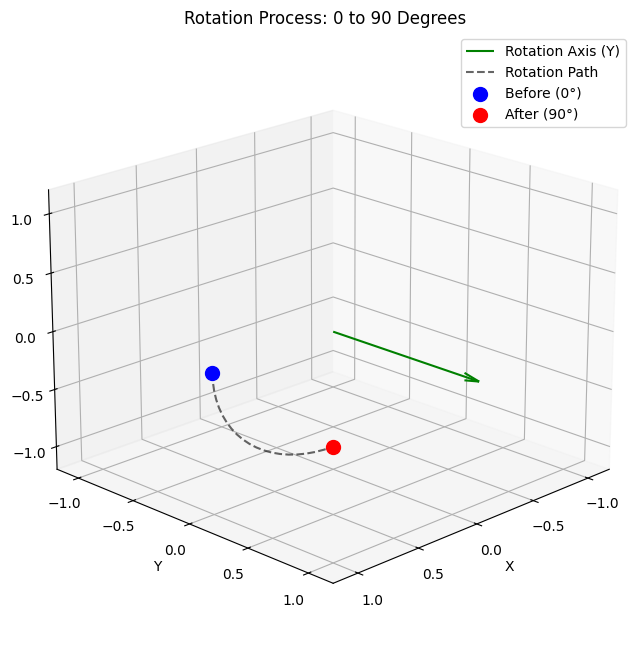

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

def visualize_rotation_with_arc(point_before, point_after, axis, title, steps=20):
    """可视化函数：展示旋转前后点、旋转轴以及中间过程的虚线弧"""
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection='3d')
    
    # 1. 画出旋转轴 (用绿色箭头表示)
    ax.quiver(0, 0, 0, axis[0], axis[1], axis[2], color='g', length=1.2, label='Rotation Axis (Y)', arrow_length_ratio=0.1)
    
    # 2. 计算中间过程的点 (弧线)
    # 我们要在 0 到 angle 之间插值
    arc_points = []
    # 假设我们已知总旋转角度是通过 90度计算的
    total_angle_rad = np.pi / 2 
    
    for i in range(steps + 1):
        # 当前步的角度
        current_angle = (i / steps) * total_angle_rad
        # 构造当前的四元数
        w = np.cos(current_angle / 2)
        xyz = np.sin(current_angle / 2) * axis
        q_current = np.array([w, xyz[0], xyz[1], xyz[2]])
        
        # 应用旋转得到中间点位置
        p_mid = qrot_np(q_current, point_before)
        arc_points.append(p_mid)
    
    arc_points = np.array(arc_points)
    
    # 3. 画出中间过程的虚线
    ax.plot(arc_points[:, 0], arc_points[:, 1], arc_points[:, 2], 'k--', alpha=0.6, label='Rotation Path')
    
    # 4. 画出旋转前后的点
    ax.scatter(point_before[0], point_before[1], point_before[2], c='b', s=100, label='Before (0°)')
    ax.scatter(point_after[0], point_after[1], point_after[2], c='r', s=100, label='After (90°)')
    
    # 5. 设置坐标轴范围和标签
    # 自动适应点的位置，稍微留白
    max_val = np.max(np.abs([point_before, point_after])) + 0.2
    ax.set_xlim([-max_val, max_val])
    ax.set_ylim([-max_val, max_val])
    ax.set_zlim([-max_val, max_val])
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_zlabel('Z')
    ax.view_init(elev=20, azim=45) # 调整视角以便看清3D效果
    ax.legend()
    ax.set_title(title)
    
    plt.show()

# --- 实验部分 ---
hand_pos = np.array([1.0, 0.0, 0.0])
axis_of_rotation = np.array([0.0, 1.0, 0.0]) # 绕 Y 轴

# 计算最终 90 度后的位置
angle_90_rad = np.deg2rad(90)
q_90 = np.array([np.cos(angle_90_rad/2), 0, np.sin(angle_90_rad/2), 0]) # 绕Y轴的四元数
rotated_hand_pos = qrot_np(q_90, hand_pos)  # 注意这一句，这就是四元数旋转

# 可视化中间过程
visualize_rotation_with_arc(hand_pos, rotated_hand_pos, axis_of_rotation, "Rotation Process: 0 to 90 Degrees")

### 破译天书：`qmul_np(q_next, qinv_np(q_current))`

现在我们来解决你最大的困惑。在理解了四元数是什么之后，我们来看它的两个核心运算：

*   **`qinv_np(q)` (求逆)**: 代表“反向旋转”。如果 `q` 是“向左转90度”，`qinv(q)` 就是“向右转90度”。
*   **`qmul_np(q1, q2)` (乘法)**: 代表“连续施加旋转”。`qmul(q1, q2)` 的意思是**先做 `q2` 旋转，再做 `q1` 旋转**。顺序很重要！

现在，我们把这行代码拆解开：
`r_velocity = qmul_np(r_rot[1:], qinv_np(r_rot[:-1]))`

*   `r_rot[:-1]`：这是**当前帧**的旋转，我们称之为 `q_current`。
*   `r_rot[1:]`：这是**下一帧**的旋转，我们称之为 `q_next`。
*   `qinv_np(r_rot[:-1])`：这是**当前帧的反向旋转**，`q_current_inv`。

所以，这行代码在计算：**`q_delta = q_next * q_current_inv`**

**这在数学上是什么意思？**
它在问一个问题：“我需要施加一个什么样的旋转 (`q_delta`)，才能从 `q_current` 状态变成 `q_next` 状态？”
这个 `q_delta` 就是两帧之间的**旋转变化量**，也就是**角速度**！

**简单说，这行代码就是在计算 “从当前姿态到下一姿态，角色转了多少”。**


---

### Part 1: 类比 - 向量世界中的“位移”

想象一个物体在 2D 空间中移动。
*   在 `t-1` 时刻，它的位置是 `P_current = (2, 3)`。
*   在 `t` 时刻，它的位置是 `P_next = (5, 4)`。

**问题**：从 `P_current` 到 `P_next` 的**位移向量 (Displacement Vector)** 是多少？我们称之为 `V`。

**推导**:
我们知道：`最终位置 = 初始位置 + 位移`
用数学公式表达就是：
$$
\mathbf{P}_{\text{next}} = \mathbf{P}_{\text{current}} + \mathbf{V}
$$
为了求出 `V`，我们只需要做一个简单的代数变换，在等式两边同时减去 `P_current`：
$$
\mathbf{V} = \mathbf{P}_{\text{next}} - \mathbf{P}_{\text{current}}
$$
在我们的例子中：
`V = (5, 4) - (2, 3) = (3, 1)`

这个 `V` 就是**线性速度 (Linear Velocity)**，它描述了位置的变化。

---

### Part 2: 四元数世界中的“旋转变化”

现在，我们把上面的逻辑应用到旋转上。
*   在 `t-1` 时刻，物体的朝向由四元数 `q_current` 描述。
*   在 `t` 时刻，物体的朝向由四元数 `q_next` 描述。

**问题**：从 `q_current` 到 `q_next` 的**旋转变化量 (Rotational Change)** 是多少？我们称之为 `Δq` (Delta q)。

**推导**:
这里的逻辑和向量世界完全一样，只是运算符不同：
*   向量的 **“加法”** 对应四元数的 **“乘法”** (代表连续施加旋转)。
*   向量的 **“减法”** 对应四元数的 **“乘以逆”** (代表施加反向旋转)。

我们的公式是：`最终朝向 = 初始朝向 应用上 旋转变化`
**重要**：这里的“应用”顺序是关键。我们是先有了初始朝向 `q_current`，然后再施加一个变化 `Δq` 得到的最终朝向 `q_next`。在四元数乘法中，这表示为：
$$
q_{\text{next}} = \Delta q \cdot q_{\text{current}}
$$
*注意：这里的乘法顺序代表 `Δq` 是在世界坐标系下施加的旋转。*

现在，我们的目标是求解 `Δq`。为此，我们需要“消除”等式右边的 `q_current`。在四元数中，要消除一个旋转，就需要乘以它的**逆 (Inverse)**，我们记作 $q_{\text{current}}^{-1}$。

我们在等式两边**同时在右侧**乘以 $q_{\text{current}}^{-1}$ (因为四元数乘法不满足交换律，所以从哪边乘很重要)：
$$
q_{\text{next}} \cdot q_{\text{current}}^{-1} = (\Delta q \cdot q_{\text{current}}) \cdot q_{\text{current}}^{-1}
$$
根据乘法结合律，右边可以写作（**注意：四元数的乘法和矩阵的乘法都具备结合律，但是不具备交换律**）：
$$
q_{\text{next}} \cdot q_{\text{current}}^{-1} = \Delta q \cdot (q_{\text{current}} \cdot q_{\text{current}}^{-1})
$$
一个四元数乘以它自身的逆，会得到**单位四元数 (Identity Quaternion)** `[1, 0, 0, 0]`，它代表“不旋转”，相当于数字世界里的 `1`。
$$
q_{\text{next}} \cdot q_{\text{current}}^{-1} = \Delta q \cdot \text{identity}
$$
所以，我们最终得到：
$$
\Delta q = q_{\text{next}} \cdot q_{\text{current}}^{-1}
$$

这个 `Δq` 就是**角速度 (Angular Velocity)**，它描述了旋转的变化。

---

### Part 3: 将数学公式与代码对应起来

现在，让我们把这个金光闪闪的公式和 HumanML3D 的代码对应起来：

**数学公式**:
$$
\Delta q = q_{\text{next}} \cdot q_{\text{current}}^{-1}
$$

**Python 代码**:
```python
r_velocity = qmul_np(r_rot[1:], qinv_np(r_rot[:-1]))
```

**逐一对应**:
*   `Δq` (旋转变化量) $\rightarrow$ `r_velocity` (根节点的角速度)
*   `q_next` (下一帧的旋转) $\rightarrow$ `r_rot[1:]`
*   `q_current` (当前帧的旋转) $\rightarrow$ `r_rot[:-1]`
*   $q_{\text{current}}^{-1}$ (当前帧的反向旋转) $\rightarrow$ `qinv_np(r_rot[:-1])`
*   `·` (四元数乘法) $\rightarrow$ `qmul_np(...)`

**结论**：这行代码的字面翻译就是 **`角速度 = 下一帧旋转 * 当前帧的反向旋转`**，它完美地实现了我们上面推导的数学公式。它计算出的 `r_velocity` 就是一个描述“从当前帧到下一帧需要转动多少”的四元数。

## Part 2: 正向动力学 (Forward Kinematics, FK)

**原理**: “我知道每个关节怎么转，请告诉我手和脚最后在哪。”

这在游戏里太常见了。动画师 K 好了每一根骨骼的旋转，引擎通过 FK 计算出每个顶点的最终位置。

FK 的过程就像一个链条：
1.  从根骨骼（Root）开始。
2.  计算子骨骼的位置 = 父骨骼的位置 + **(旋转父骨骼的朝向)** $\rightarrow$ 得到子骨骼的朝向 $\rightarrow$ 再乘以骨骼长度。
3.  不断重复，直到末端。

`common.skeleton.py` 里的 `Skeleton` 类已经帮我们封装好了这个链式计算。在这个接口中：<span style="color:orange;">你提供给 FK 函数的四元数，永远是【相对于父节点的局部旋转】(Local, Parent-Relative Rotation)。</span>

In [4]:
import plotly.graph_objects as go
import numpy as np

def interactive_pose_viewer_single(pose, title="Drag to Rotate"):
    """
    针对单帧 (22x3) 的可交互可视化
    """
    # 确保维度正确 (22, 3)
    pose = np.array(pose)
    if pose.shape != (22, 3):
        raise ValueError(f"期望输入形状为 (22, 3)，但收到的是 {pose.shape}")

    # 映射坐标: X=X, Y=Z(Depth), Z=Y(Height)
    xs, ys, zs = pose[:, 0], pose[:, 2], pose[:, 1]

    fig = go.Figure()

    # 1. 绘制关节 (散点)
    fig.add_trace(go.Scatter3d(
        x=xs, y=ys, z=zs,
        mode='markers',
        marker=dict(size=5, color='black', opacity=0.8),
        name='Joints'
    ))

    # 2. 定义骨骼链并绘制 (线段)
    chains = {
        'Left':  {'links': [[0,1],[1,4],[4,7],[7,10],[9,13],[13,16],[16,18],[18,20]], 'color': 'red'},
        'Right': {'links': [[0,2],[2,5],[5,8],[8,11],[9,14],[14,17],[17,19],[19,21]], 'color': 'blue'},
        'Spine': {'links': [[0,3],[3,6],[6,9],[9,12]], 'color': 'black'}
    }

    for name, info in chains.items():
        for link in info['links']:
            fig.add_trace(go.Scatter3d(
                x=[xs[link[0]], xs[link[1]]],
                y=[ys[link[0]], ys[link[1]]],
                z=[zs[link[0]], zs[link[1]]],
                mode='lines',
                line=dict(color=info['color'], width=6),
                showlegend=False
            ))

    # 3. 设置布局与视角
    fig.update_layout(
        title=title,
        scene=dict(
            xaxis=dict(range=[-0.8, 0.8], title='X'),
            yaxis=dict(range=[-0.8, 0.8], title='Z (Depth)'),
            zaxis=dict(range=[0, 1.8], title='Y (Height)'),
            aspectmode='manual',
            aspectratio=dict(x=1, y=1, z=1.2), # 稍微拉长高度比例
            camera=dict(eye=dict(x=1.5, y=1.5, z=1.0)) # 默认起始视角
        ),
        margin=dict(l=0, r=0, b=0, t=40)
    )

    fig.show()

# 1. 初始化骨架 (代码同前)
n_raw_offsets = torch.from_numpy(t2m_raw_offsets)
kinematic_chain = t2m_kinematic_chain
try:
    ref_data = np.load("/root/autodl-tmp/HumanML3D/HumanML3D/joints/000021.npy")
    ref_data_tensor = torch.from_numpy(ref_data.reshape(len(ref_data), -1, 3))
    skeleton = Skeleton(n_raw_offsets, kinematic_chain, 'cpu')
    tgt_offsets = skeleton.get_offsets_joints(ref_data_tensor[0])
    skeleton.set_offset(tgt_offsets)
    print("标准骨架加载成功！")
except Exception as e:
    print(f"警告: 加载参考骨架失败 ({e})，FK/IK 可能不准确。")
    skeleton = Skeleton(n_raw_offsets, kinematic_chain, 'cpu')

# 2. 定义根节点位置
root_pos = np.array([0.0, 0.8, 0.0]) 

# 3. 定义关节旋转
num_joints = 22
joint_rotations = np.zeros((1, num_joints, 4))
joint_rotations[:, :, 0] = 1.0 # 默认 T-Pose (单位四元数)

# --- 摆一个更自然的 Pose ---
# 让右肩 (索引17) 侧向抬起 60 度 (绕 Z 轴)
angle_rad = np.deg2rad(60)
axis = np.array([0, 0, 1]) # Z 轴
w = np.cos(angle_rad / 2)
xyz = np.sin(angle_rad / 2) * axis
right_shoulder_rot = np.array([w, xyz[0], xyz[1], xyz[2]])
joint_rotations[0, 17] = right_shoulder_rot

# CORRECTED: 让右手肘 (索引19) 弯曲 90 度
# 为了实现自然的弯曲，我们应该绕 Y 轴旋转，就像做二头肌弯举一样
angle_rad = np.deg2rad(-90) # 负角度向内弯曲
axis = np.array([0, 1, 0]) # <--- 修正了旋转轴
w = np.cos(angle_rad / 2)
xyz = np.sin(angle_rad / 2) * axis
right_elbow_rot = np.array([w, xyz[0], xyz[1], xyz[2]])
joint_rotations[0, 19] = right_elbow_rot

# 4. 调用 FK
final_pose = skeleton.forward_kinematics_np(joint_rotations, root_pos[np.newaxis, :]).squeeze()
print("final pose shape:", final_pose.shape) # 应该是 (22, 3)

# 5. 可视化！
interactive_pose_viewer_single(final_pose)

标准骨架加载成功！
final pose shape: (22, 3)
